## NN simulation
The parameters are hereby predicted using a simple NN to capture the non-linear dynamics

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim



In [6]:
data = np.load("dataset_mc_ml_v1_prepared.npz")

X_train = torch.tensor(data["X_train"], dtype=torch.float32)
y_train = torch.tensor(data["y_train"], dtype=torch.float32)

X_val = torch.tensor(data["X_val"], dtype=torch.float32)
y_val = torch.tensor(data["y_val"], dtype=torch.float32)

X_test = torch.tensor(data["X_test"], dtype=torch.float32)
y_test = torch.tensor(data["y_test"], dtype=torch.float32)


In [7]:
class ParamNet(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=32, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
model = ParamNet()


In [9]:
criterion = nn.MSELoss()


In [10]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [11]:
n_epochs = 500
patience = 30

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # --- TRAIN ---
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train)
    train_loss = criterion(y_pred, y_train)
    train_loss.backward()
    optimizer.step()

    # --- VALIDATION ---
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict()
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train {train_loss:.4f} | Val {val_loss:.4f}")


Epoch    0 | Train 1.1281 | Val 0.9973
Epoch   50 | Train 0.1976 | Val 0.1509
Epoch  100 | Train 0.1540 | Val 0.1216
Epoch  150 | Train 0.1275 | Val 0.1144
Epoch  200 | Train 0.1168 | Val 0.1105
Epoch  250 | Train 0.1098 | Val 0.1087
Early stopping at epoch 270


In [12]:
model.load_state_dict(best_state)


<All keys matched successfully>

In [13]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test).numpy()

y_test_np = y_test.numpy()


In [14]:
from sklearn.metrics import r2_score

print("=== NN R^2 (test set) ===")
for i, name in enumerate(["theta_cost", "theta_cong"]):
    r2 = r2_score(y_test_np[:, i], y_test_pred[:, i])
    print(f"{name}: R^2 = {r2:.3f}")


=== NN R^2 (test set) ===
theta_cost: R^2 = -0.156
theta_cong: R^2 = -0.262


9️⃣ Come interpretare l’esito 

Caso A — R² > 0 (anche 0.2–0.4)

👉 Risultato forte

•	identificabilità non lineare

•	NN necessaria

•	ML giustificato

Caso B — R² ≈ 0

👉 Risultato altrettanto forte

•	parametri non identificabili

•	anche modelli flessibili falliscono

•	serve informazione diversa (shock, microdata)



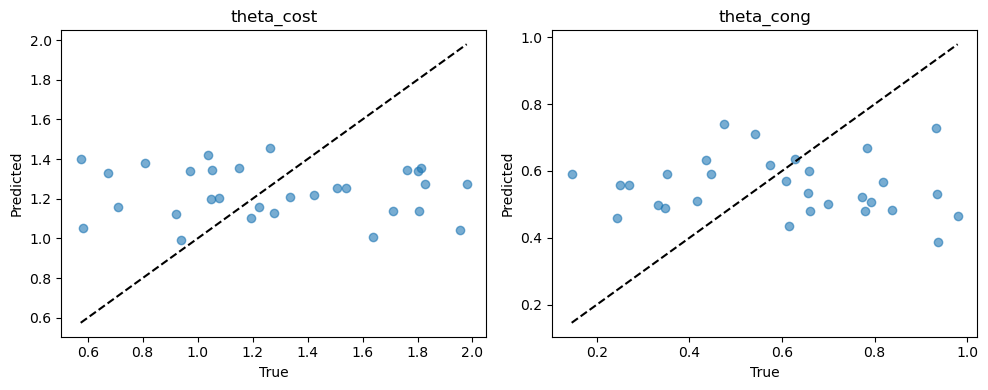

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, name in enumerate(["theta_cost", "theta_cong"]):
    axes[i].scatter(y_test_np[:, i], y_test_pred[:, i], alpha=0.6)
    axes[i].plot(
        [y_test_np[:, i].min(), y_test_np[:, i].max()],
        [y_test_np[:, i].min(), y_test_np[:, i].max()],
        "k--"
    )
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Predicted")
    axes[i].set_title(name)

plt.tight_layout()
plt.show()


While point identification of structural parameters is infeasible, aggregate observables allow robust classification of market regimes with clear economic interpretation.